<a target="_blank" href="https://colab.research.google.com/github/lukebarousse/Python_Data_Analytics_Course/blob/main/4_Problems/1_24_Pandas Inspection.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [2]:

import pandas as pd
df = pd.read_csv("hf://datasets/lukebarousse/data_jobs/data_jobs.csv")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


---

## 🟩 Access Third Row (1.24.1)

In [15]:
df.iloc[3]

,3
job_title_short,Data Engineer
job_title,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...
job_location,"San Antonio, TX"
job_via,via Diversity.com
job_schedule_type,Full-time
job_work_from_home,False
search_location,"Texas, United States"
job_posted_date,2023-07-04 13:01:41
job_no_degree_mention,True
job_health_insurance,False


---

## 🟨 Unique Job Countries (1.24.2)

In [16]:
df.job_country.unique()

array(['United States', 'Mexico', 'Germany', 'Sudan', 'Romania',
       'Denmark', 'Switzerland', 'France', 'Brazil', 'United Kingdom',
       'India', 'Poland', 'Belgium', 'Russia', 'Serbia', 'Singapore',
       'Costa Rica', 'Ireland', 'Italy', 'Malaysia', 'Canada', 'Uruguay',
       'Namibia', 'Estonia', 'Israel', 'Hungary', 'Austria',
       'Philippines', 'Egypt', 'Australia', 'Chile', 'Spain',
       'Netherlands', 'South Africa', 'Colombia', 'Hong Kong', 'Kuwait',
       'Finland', 'Luxembourg', 'China', 'Puerto Rico', 'Sweden',
       'Saudi Arabia', 'Argentina', 'Turkey', 'Panama', 'Nigeria',
       'New Zealand', 'Ukraine', 'Jordan', 'United Arab Emirates',
       'Armenia', 'Pakistan', 'Lesotho', 'Mauritius', 'Portugal',
       'Bahrain', 'Taiwan', "Côte d'Ivoire", 'U.S. Virgin Islands',
       'Réunion', 'Kazakhstan', 'Lithuania', 'Moldova', 'Belarus',
       'Cyprus', 'Bulgaria', 'Honduras', 'Czechia', 'Peru', 'South Korea',
       'Malta', 'Indonesia', 'Tunisia', 'Latvia'

---

## 🟨 Filter by Job Schedule Type and Display (1.24.3)

In [19]:
df.job_schedule_type.unique()

array(['Full-time', 'Contractor and Temp work',
       'Full-time and Internship', 'Temp work', 'Contractor',
       'Full-time and Part-time', 'Full-time and Temp work',
       'Full-time and Contractor', 'Part-time', 'Internship', nan,
       'Part-time and Contractor', 'Temp work and Internship',
       'Full-time, Part-time, and Contractor',
       'Full-time, Part-time, and Internship',
       'Full-time, Contractor, and Temp work',
       'Full-time, Part-time, and Temp work',
       'Full-time, Temp work, and Internship',
       'Full-time, Contractor, and Internship',
       'Part-time and Internship', 'Contractor and Internship',
       'Part-time and Full-time', 'Part-time and Temp work',
       'Full-time and Volunteer', 'Contractor, Temp work, and Internship',
       'Full-time and Per diem', 'Per diem', 'Volunteer',
       'Part-time, Contractor, and Temp work',
       'Full-time, Temp work, and Per diem',
       'Part-time, Temp work, and Internship', 'Contractor and Part

---

## 🟥 Check Missing Values (1.24.4)

In [20]:
df.isna().sum()

,0
job_title_short,0
job_title,1
job_location,1045
job_via,8
job_schedule_type,12667
job_work_from_home,0
search_location,0
job_posted_date,0
job_no_degree_mention,0
job_health_insurance,0


In [21]:
df.job_posted_date[0]

'2023-06-16 13:44:15'

In [27]:
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)

In [37]:
df['job_posted_month']=df['job_posted_date'].dt.month

In [31]:
df.sort_values(by='job_posted_month', inplace=True)

In [32]:
df.drop(labels='salary_hour_avg', axis=1, inplace=True)

In [33]:
df.dropna(subset=['salary_year_avg'], inplace=True)

In [38]:
df.describe()

,job_posted_date,salary_year_avg,salary_hour_avg,job_posted_month
count,785741,22003.000000,10662.000000,785741.000000
mean,2023-06-25 16:02:11.860248576,123286.274072,47.016598,6.305538
min,2023-01-01 00:00:04,15000.000000,8.000000,1.000000
25%,2023-03-20 10:05:48,90000.000000,27.500000,3.000000
50%,2023-06-29 06:11:38,115000.000000,45.980000,6.000000
75%,2023-09-27 01:01:16,150000.000000,61.159996,9.000000
max,2023-12-31 23:59:58,960000.000000,391.000000,12.000000
std,NaN,48312.449482,21.890738,3.525408


---

In [40]:
df.job_title_short.value_counts()

,count
job_title_short,
Data Analyst,196075
Data Engineer,186241
Data Scientist,172286
Business Analyst,49063
Software Engineer,44929
Senior Data Engineer,44563
Senior Data Scientist,36957
Senior Data Analyst,29216
Machine Learning Engineer,14080


In [42]:
df.salary_year_avg.idxmin()

665729

In [43]:
df.salary_year_avg.min()

15000.0

In [44]:
df.iloc[665729]

,665729
job_title_short,Data Engineer
job_title,Data Engineer - Hadoop
job_location,Brazil
job_via,via LinkedIn
job_schedule_type,Full-time
job_work_from_home,False
search_location,Brazil
job_posted_date,2023-12-09 10:05:30
job_no_degree_mention,True
job_health_insurance,False


In [52]:
df1 = df.groupby('job_title_short')['salary_year_avg'].agg(['mean', 'min']).sort_values(ascending=False, by='mean')

<Axes: title={'center': 'Jobs by highest mean salary and min salary'}, xlabel='Job Titles', ylabel='US dollars'>

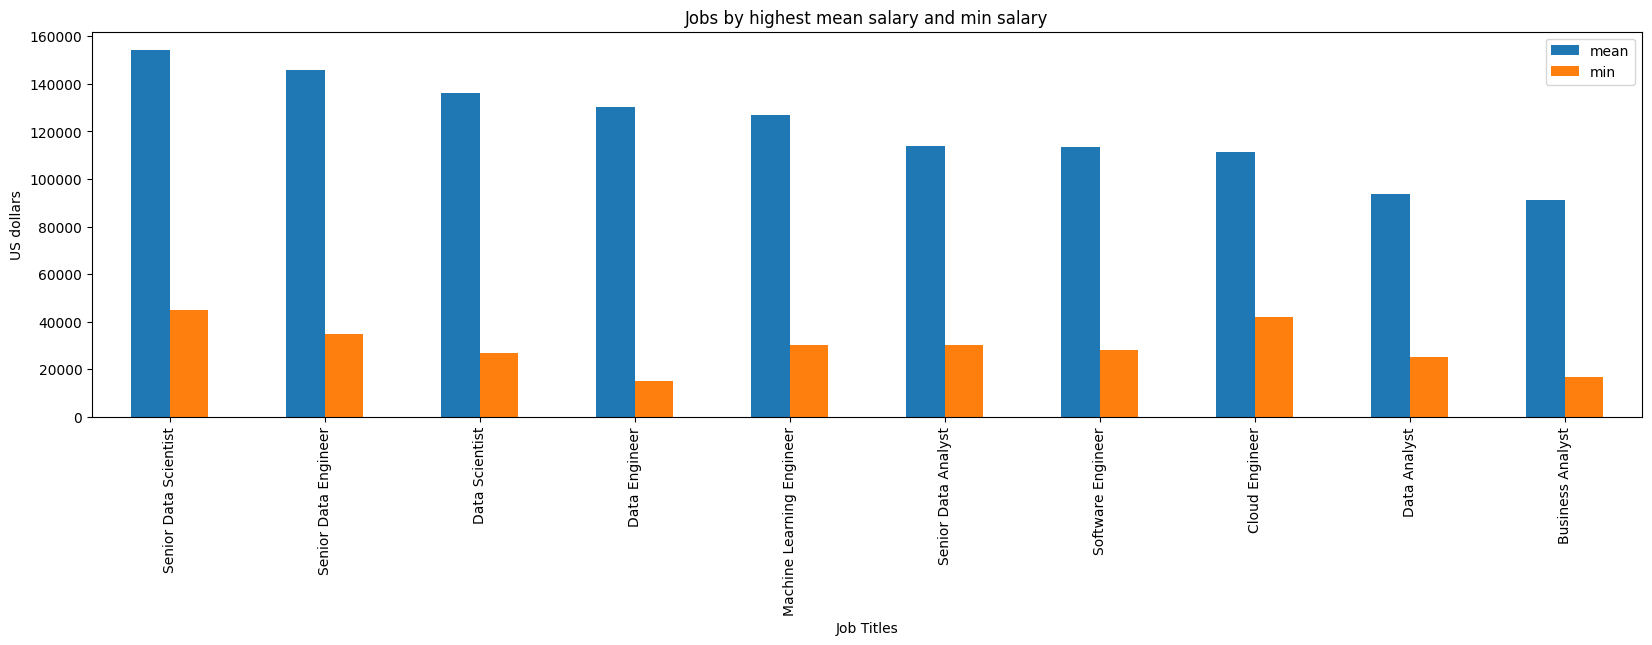

In [60]:
df1.plot(kind='bar', figsize=(20,5), title='Jobs by highest mean salary and min salary', ylabel='US dollars', xlabel='Job Titles')

In [6]:
(df.job_country == 'Slovakia').value_counts()

,count
job_country,
False,784777
True,964


In [8]:
df_slovakia = df[df.job_country == 'Slovakia']

In [9]:
df_slovakia

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
740,Data Engineer,Cardo Health - Data Engineer (Contract) - Remo...,Anywhere,via Jobgether,Full-time and Contractor,True,Slovakia,2023-12-13 14:16:02,False,False,Slovakia,NaN,NaN,NaN,techruiter.,"['python', 'postgresql']","{'databases': ['postgresql'], 'programming': [..."
967,Senior Data Scientist,Senior Advanced Analytics Analyst,"Bratislava, Slovakia",via Jobs At Medtronic,Full-time,False,Slovakia,2023-09-13 13:29:30,False,False,Slovakia,NaN,NaN,NaN,Medtronic,"['power bi', 'excel']","{'analyst_tools': ['power bi', 'excel']}"
1480,Data Engineer,Junior/Medior Data Engineer IRC176220,Anywhere,via LinkedIn Slovakia,Full-time,True,Slovakia,2023-02-22 13:58:28,True,False,Slovakia,NaN,NaN,NaN,GlobalLogic,"['scala', 'sql', 'databricks', 'snowflake', 'a...","{'cloud': ['databricks', 'snowflake', 'azure']..."
1648,Software Engineer,DevOps Engineer,Anywhere,via LinkedIn Slovakia,Full-time,True,Slovakia,2023-03-08 14:16:38,False,False,Slovakia,NaN,NaN,NaN,Sportradar,"['python', 'go', 'aws', 'kubernetes', 'terrafo...","{'cloud': ['aws'], 'other': ['kubernetes', 'te..."
1930,Data Engineer,Data Engineer,"Bratislava, Slovakia",via LinkedIn Slovakia,Full-time,False,Slovakia,2023-06-30 13:31:14,False,False,Slovakia,NaN,NaN,NaN,SuperScale,['sql'],{'programming': ['sql']}
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
773967,Senior Data Scientist,Senior Data Scientist,"Bratislava, Slovakia",via LinkedIn Slovakia,Full-time,False,Slovakia,2023-02-25 02:07:22,False,False,Slovakia,NaN,NaN,NaN,AT&T,"['python', 'r', 'scala', 'sql', 'pandas', 'pyt...","{'libraries': ['pandas', 'pytorch', 'tidyverse..."
774402,Business Analyst,Reinsurance Account Analyst,"Bratislava, Slovakia",via Swiss Re Careers,Full-time,False,Slovakia,2023-09-21 01:49:25,False,False,Slovakia,NaN,NaN,NaN,Swiss Re,"['excel', 'word', 'flow']","{'analyst_tools': ['excel', 'word'], 'other': ..."
775833,Software Engineer,"Senior Staff Software Engineer (Java, Rust) - ...",Slovakia,via Ai-Jobs.net,Full-time,False,Slovakia,2023-02-21 02:06:01,True,False,Slovakia,year,89100.0,NaN,SentinelOne,"['java', 'go', 'python', 'scala', 'rust', 'aws...","{'analyst_tools': ['splunk'], 'cloud': ['aws',..."
776020,Software Engineer,Application Operation Engineer,"Bratislava, Slovakia",via BeBee,Full-time,False,Slovakia,2023-07-26 01:36:24,True,False,Slovakia,NaN,NaN,NaN,Swiss Re,"['java', 'python', 'javascript', 'powershell',...","{'async': ['jira', 'confluence'], 'cloud': ['a..."


In [10]:
df_slovakia.info()

<class 'pandas.core.frame.DataFrame'>
Index: 964 entries, 740 to 776141
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   job_title_short        964 non-null    object 
 1   job_title              964 non-null    object 
 2   job_location           964 non-null    object 
 3   job_via                964 non-null    object 
 4   job_schedule_type      962 non-null    object 
 5   job_work_from_home     964 non-null    bool   
 6   search_location        964 non-null    object 
 7   job_posted_date        964 non-null    object 
 8   job_no_degree_mention  964 non-null    bool   
 9   job_health_insurance   964 non-null    bool   
 10  job_country            964 non-null    object 
 11  salary_rate            16 non-null     object 
 12  salary_year_avg        16 non-null     float64
 13  salary_hour_avg        0 non-null      float64
 14  company_name           964 non-null    object 
 15  job_sk

In [16]:
df_clean = df_slovakia[df_slovakia.salary_year_avg.notna()]

In [17]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16 entries, 110367 to 776141
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   job_title_short        16 non-null     object 
 1   job_title              16 non-null     object 
 2   job_location           16 non-null     object 
 3   job_via                16 non-null     object 
 4   job_schedule_type      16 non-null     object 
 5   job_work_from_home     16 non-null     bool   
 6   search_location        16 non-null     object 
 7   job_posted_date        16 non-null     object 
 8   job_no_degree_mention  16 non-null     bool   
 9   job_health_insurance   16 non-null     bool   
 10  job_country            16 non-null     object 
 11  salary_rate            16 non-null     object 
 12  salary_year_avg        16 non-null     float64
 13  salary_hour_avg        0 non-null      float64
 14  company_name           16 non-null     object 
 15  job_

In [23]:
df_graph = df_clean.groupby('job_title_short')['salary_year_avg'].agg(['median', 'mean', 'min', 'max', 'count']).sort_values(ascending=False, by='median')

In [22]:
import matplotlib.pyplot as plt

<Axes: title={'center': 'Jobs in Slovakia by median salary'}, xlabel='Job Titles', ylabel='US dollars'>

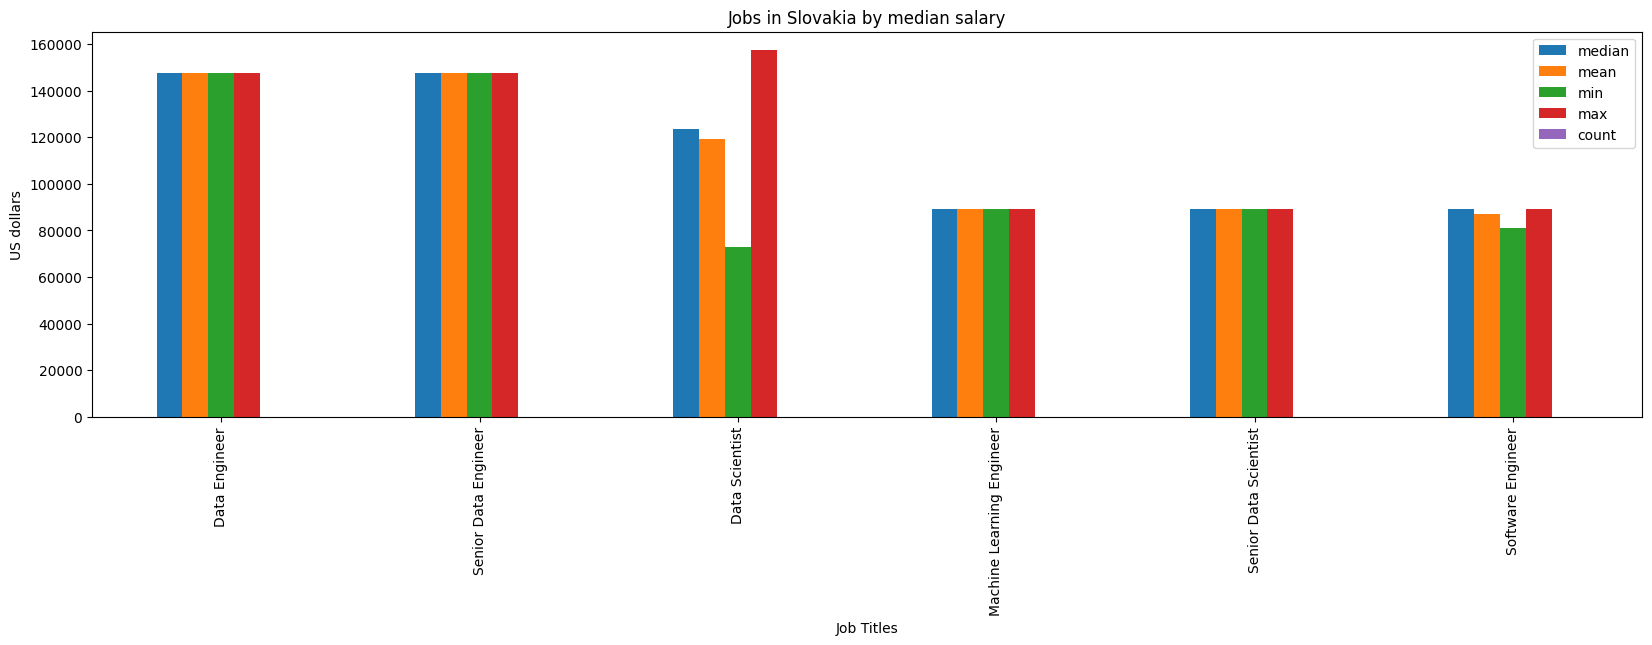

In [26]:
df_graph.plot(kind='bar', figsize=(20,5), title='Jobs in Slovakia by median salary', ylabel='US dollars', xlabel='Job Titles')

<Axes: xlabel='job_posted_month'>

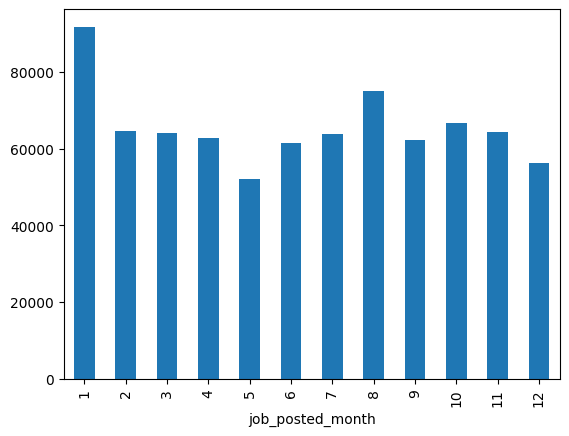

In [36]:

df['job_posted_month']=df['job_posted_date'].dt.month
df.job_posted_month.value_counts().sort_index().plot(kind='bar')

<Axes: title={'center': 'Jobs by title'}, ylabel='job_title_short'>

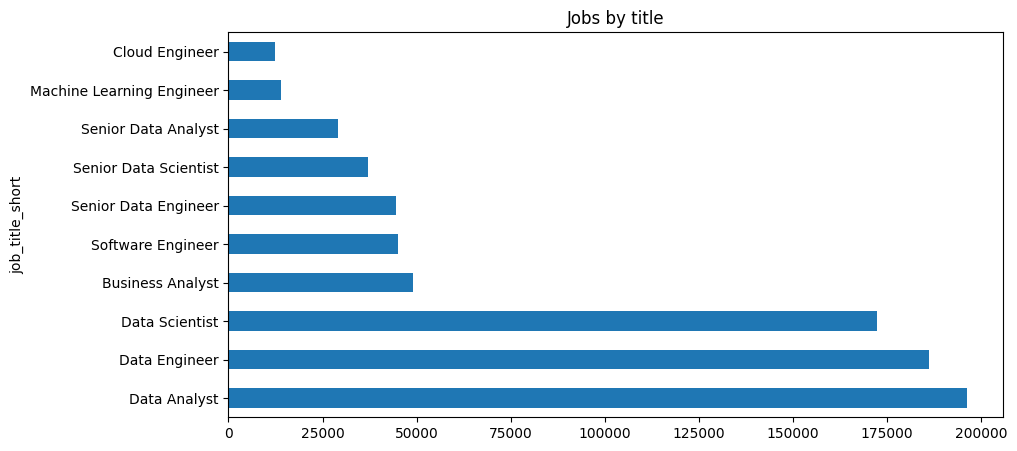

In [44]:
df.job_title_short.value_counts().plot(kind='barh', figsize=(10,5), title='Jobs by title')

In [46]:
df_1 = df.job_title_short.value_counts()

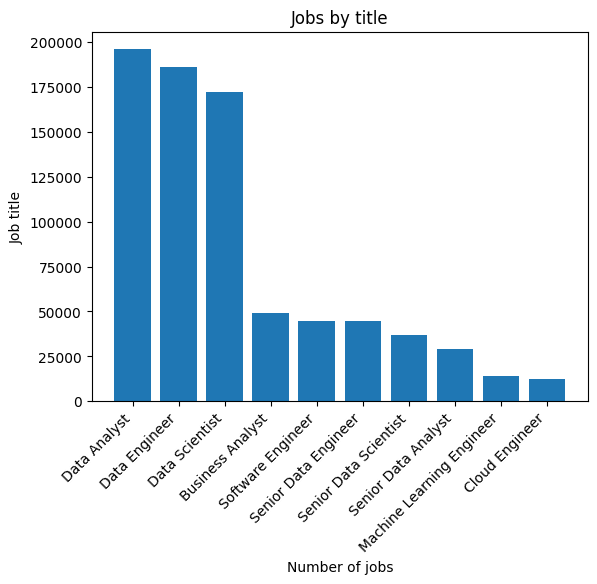

In [58]:
plt.bar(df_1.index, df_1)
plt.title('Jobs by title')
plt.xlabel('Number of jobs')
plt.ylabel('Job title')
plt.xticks(rotation=45, ha='right')
plt.show()